#Descriptive Statistics

##Introduction

The objective here is to use the cleaned data that we collected in the "Manipulating Data with Pandas" document, so we can run some statistical analysis and make conclusions with the use of the data.

##Library imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats # A good statistical module from the scipy library

##Data import

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/nicolas-almeida-v/pandas-descriptive-statistics-us-surgery/refs/heads/main/cleaned_surgery.csv')

In [3]:
df.head()

,City,Procedure,No. of Surgeons,Surgeon Volume,Average Price ($),Minimum Price ($),Maximum Price ($),Top Rated Surgeon,More Information
0,Tampa,Tummy Tuck,419,High,8512.0,7000.0,14000.0,Dr. John Roach,https://www.aestheticmatch.com/cities/tampa
1,Tampa,Breast Reduction,169,High,12712.0,6000.0,11200.0,"Dr. Traci Temmen, MD",https://www.aestheticmatch.com/cities/tampa
2,Tampa,Liposuction,156,High,8960.0,4000.0,11000.0,Dr. Traci Temmen,https://www.aestheticmatch.com/cities/tampa
3,Tampa,Breast Implants,152,High,6384.0,4500.0,6500.0,Dr. Jaime Perez,https://www.aestheticmatch.com/cities/tampa
4,Tampa,Facelift,147,Intermediate,13776.0,8900.0,17000.0,"Dr. Demetri Arnaoutakis, MD",https://www.aestheticmatch.com/cities/tampa


###Examining the dataframe

In [4]:
#598 rows and 9 columns
df.shape

(598, 9)

In [5]:
df.columns #Columns names

Index(['City', 'Procedure', 'No. of Surgeons', 'Surgeon Volume',
       'Average Price ($)', 'Minimum Price ($)', 'Maximum Price ($)',
       'Top Rated Surgeon', 'More Information'],
      dtype='object')

In [6]:
df.dtypes #Data types of each columns

,0
City,object
Procedure,object
No. of Surgeons,int64
Surgeon Volume,object
Average Price ($),float64
Minimum Price ($),float64
Maximum Price ($),float64
Top Rated Surgeon,object
More Information,object


##Counting

###Frequencies

In [7]:
#Counting how many procedures were made (absolute frequencies)
df['Procedure'].value_counts()

,count
Procedure,
Breast Reduction,100
Liposuction,100
Nose Plastic Surgery (Rhinoplasty),100
Breast Implants,100
Tummy Tuck,99
Facelift,99


We see the absolute frequencies of each procedures but with the `normalize=True` statement, we could see the relative frequencies

In [8]:
#Counting how many procedures were made (relative frequencies)
df['Procedure'].value_counts(normalize=True)

,proportion
Procedure,
Breast Reduction,0.167224
Liposuction,0.167224
Nose Plastic Surgery (Rhinoplasty),0.167224
Breast Implants,0.167224
Tummy Tuck,0.165552
Facelift,0.165552


###Gruped frequencies

In [9]:
#Counting frequencies of procedures and surgeon volumes
pd.crosstab(df['Procedure'], df['Surgeon Volume'])

Surgeon Volume,High,Intermediate,Low
Procedure,,,
Breast Implants,19,42,39
Breast Reduction,22,46,32
Facelift,13,42,44
Liposuction,17,43,40
Nose Plastic Surgery (Rhinoplasty),20,49,31
Tummy Tuck,44,46,9


##Measures of central tendency (point estimates)

###Arithmetic Mean

In [10]:
#What is the mean of Average Price ($) in all procedures
df['Average Price ($)'].mean()

np.float64(11009.084949832775)

In [11]:
#What is the mean of Minimum Price ($) in of all Tummy tuck procedures
df[df['Procedure'] == 'Tummy Tuck']['Minimum Price ($)'].mean()

np.float64(6903.939393939394)

In [12]:
#Table of procedures with their respective arithmetic mean minimum price
df.groupby('Procedure')['Minimum Price ($)'].mean()

,Minimum Price ($)
Procedure,
Breast Implants,5759.350000
Breast Reduction,7048.630000
Facelift,8320.757576
Liposuction,3515.410000
Nose Plastic Surgery (Rhinoplasty),5873.140000
Tummy Tuck,6903.939394


###Geometric Mean

Let's remember that the arithmetic mean is used for additive data, like test scores, while the geometric mean is better for multiplicative data, such as percentage changes, growth rates, and financial indices.

In the current work I don't feel the need to use the geometric mean, but if i were to use, this is the code to use: `stats.gmean(df)`

###Median

In cases that we don't have a nice bell-shaped curve because there are some extreme data values, we cannot rely much on the mean, but on median.

In [13]:
#What is the median of Average Price ($) in all procedures?
df['Average Price ($)'].median()

10192.0

In [14]:
#What is the median of Minimum Price ($) in of all Tummy tuck procedures?
df[df['Procedure'] == 'Tummy Tuck']['Minimum Price ($)'].median()

6525.0

In [15]:
#Table of procedures with their respective median minimum price
df.groupby('Procedure')['Minimum Price ($)'].median()

,Minimum Price ($)
Procedure,
Breast Implants,6000.0
Breast Reduction,6250.0
Facelift,7000.0
Liposuction,3100.0
Nose Plastic Surgery (Rhinoplasty),6000.0
Tummy Tuck,6525.0


###Mode

The mode is the most frequently occurring value in a data set. It is particularly used for nominal (categorical) data types

We use the `.value_counts()` method do calculate the frequency.  The `ascending=` argument is set to `False` by default and the `sort=` is set to `True`, such that we get the mode at the top.

In [16]:
#Calculating the mode of 'Surgeon Volume'
df['Surgeon Volume'].value_counts(ascending=False) #Using .value_counts

,count
Surgeon Volume,
Intermediate,268
Low,195
High,135


In [17]:
#Calculating the mode of 'No.of Surgeons'
stats.mode(df['No. of Surgeons']) #Using scipy.stats.mode()

ModeResult(mode=np.int64(0), count=np.int64(26))

The previous code output is read as: The most repeated number in the column 'No. of Surgeons' is `0`, and it is repeated 26 times

##Measures of dispersion

###Standard Deviation

Standard deviation is the statistical measure of the dispersion or spread of data points around the mean (average) of a dataset.

In [18]:
#Standard Deviation of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].std()

105.725588198884

In [19]:
#Variance of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].var()

11177.9

In [20]:
#Mean of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].mean()

np.float64(205.5)

In [21]:
#Coefficient of variation of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].std()/df[df['City']=='Tampa']['No. of Surgeons'].mean()

np.float64(0.5144797479264428)

As wer can see here, in Tampa, the mean number of surgeons available is 205.5 with a standard deviation of 105.73, therefore the coefficient of variation is 51%

We can conclude that there is a great degree of variability relative to the mean in No. of Surgeons in Tampa

###Range

We can now know the range by calculating the `min` and `max` value in a dataframe

In [22]:
#Minimum value in No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].min()

147

In [23]:
#Maximum value in No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].max()

419

In [24]:
#Range of No. of Surgeons in Tampa dataframe
df[df['City']=='Tampa']['No. of Surgeons'].max() - df[df['City']=='Tampa']['No. of Surgeons'].min()

272

###Quantiles

Quantiles are values that divides a sorted dataset or a probability distribution into equal parts.

For example: Q1 = 25%, Q2 = 50%, Q3 = 75%

This is usually the distribution percentages by each quantiles

In [25]:
#Quartiles of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].quantile([0, 0.25, 0.5, 0.75, 1])

,No. of Surgeons
0.00,147.00
0.25,153.00
0.50,162.50
0.75,184.75
1.00,419.00


In [26]:
#Interquartile range of No. of Surgeons in Tampa
df[df['City']=='Tampa']['No. of Surgeons'].quantile(0.75) - df[df['City']=='Tampa']['No. of Surgeons'].quantile(0.25)

np.float64(31.75)

Usually the only quantiles that are presented are Q1, Q2 and Q3, but Q0 (min value) and Q4 (max value) can be represented to take a good look on how our data is distributed

But here, we found some problems regarding the distribution of the data.

1. If the mean is 205.5, the standard deviation is 105.73 and the minimum value is 147, it doesn't really make sense the rule of standard deviation in normally distributed data. If the data here would be normally distributed, it would look like this

Min value = `Mean` - 3 x `SD` = 205.5 - 317.19 = -111.69

Max value = `Mean` + 3 x `SD` = 205.5 + 317.19 = 522.69

2. Looking at the quartiles, we can see that there is low variability of data on the Q1, Q2 and Q3, but there is a big jump on Q4. Meaning that this data is not normally distributed and probably it is sweked to the right

#How to tell if the data is normally distributed

There mainly 2 ways: using visual methods and statistical tests.

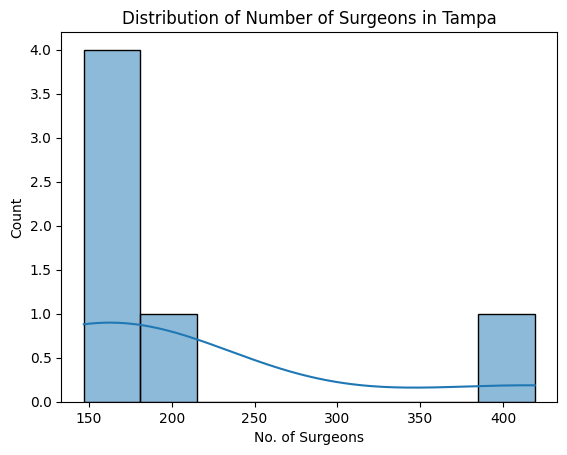

In [27]:
#Histogram of Distribution of No. of Surgeons in Tampa
sns.histplot(df[df['City']=='Tampa']['No. of Surgeons'], kde=True)
plt.title('Distribution of Number of Surgeons in Tampa')
plt.show()

Once we did that, we conclude that it was obvious that the dataframe of 'No. of Surgeons in Tampa' would be not normally distributed, as there are only 6 rows of data for surgeons in Tampa.

Now, let's see what happens if we make an histogram of No. of Surgeons in all states

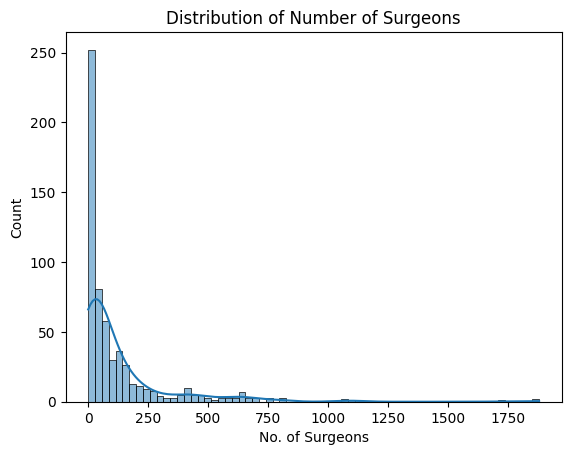

In [28]:
#Histogram of Distribution of No. of Surgeons all States
sns.histplot(df['No. of Surgeons'], kde=True)
plt.title('Distribution of Number of Surgeons')
plt.show()

With this information, we can conclude that the Distribution of Number of Surgeons in all States is neither normally distributed. But we get to see that there are many places where the number of surgeons is actually zero.

Now let's see what happens if we analyze the Distribution by histogram visualization of Average Price ($) for all procedures

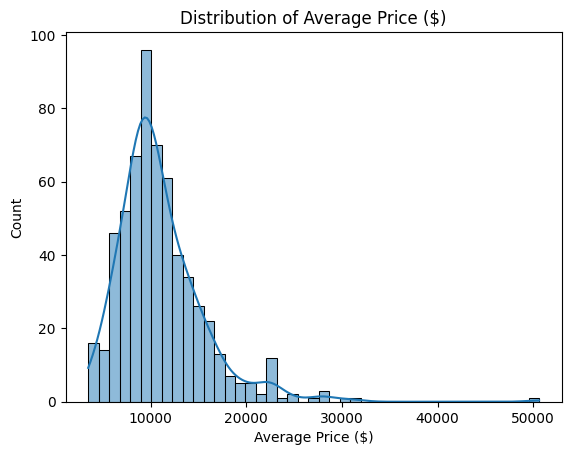

In [29]:
#Histogram of Distribution of Average Price ($) for all procedures in all states
sns.histplot(df['Average Price ($)'], kde=True)
plt.title('Distribution of Average Price ($)')
plt.show()

With this visualization is easier to get to know the distribution of the data. We can tell that the data is skewed to the right following the pattern `mode < median < mean`

Let's confirm this pattern by actually calculating this values

In [30]:
#Mode of Average Price ($) of all procedures and all states
stats.mode(df['Average Price ($)'])

ModeResult(mode=np.float64(9072.0), count=np.int64(15))

In [31]:
#Median of Average Price ($) of all procedures and all states
df['Average Price ($)'].median()

10192.0

In [32]:
#Mean of Average Price ($) of all procedures and all states
df['Average Price ($)'].mean()

np.float64(11009.084949832775)

This pattern was confirmed:

9072 < 10192 < 11009
(mode < median < mean)